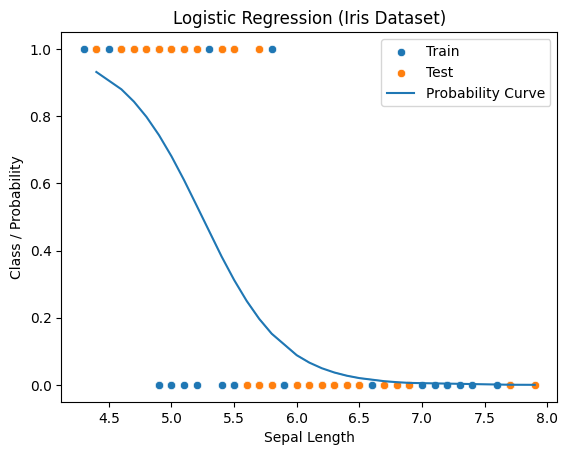

Coefficient: -3.088725487188623
Intercept: 16.19885715682372
Accuracy: 0.8666666666666667


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
df = pd.DataFrame(load_iris().data, columns=load_iris().feature_names)

X = df[['sepal length (cm)']]
y = (load_iris().target == 0).astype(int)   # binary (setosa vs rest)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = LogisticRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# Plot (Seaborn)
sns.scatterplot(x=X_train.squeeze(), y=y_train, label='Train')
sns.scatterplot(x=X_test.squeeze(), y=y_test, label='Test')
sns.lineplot(x=X_test.squeeze(), y=y_prob, label='Probability Curve')

plt.title("Logistic Regression (Iris Dataset)")
plt.xlabel("Sepal Length")
plt.ylabel("Class / Probability")
plt.show()

# Metrics
print("Coefficient:", model.coef_[0][0])
print("Intercept:", model.intercept_[0])
print("Accuracy:", accuracy_score(y_test, y_pred))